In [5]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


In [6]:
file_path = next(Path.cwd().rglob("Membership.xlsx"))
df_membership = pd.read_excel(file_path)

feature_cols = [
    "amount",
    "billing_method",
    "concurrent_streams",
    "promotion_yn",
    "is_churn_prevented",
    "payment_device",
    "is_user_verified",
    "gender",
    "age",
    "reg_hour",
]

df_baseline = df_membership[feature_cols + ["repurchase"]].copy()
df_baseline["target"] = df_baseline["repurchase"].ne("O").astype(int)

numeric_features = ["amount", "age", "reg_hour"]
categorical_features = [
    "billing_method",
    "concurrent_streams",
    "promotion_yn",
    "is_churn_prevented",
    "payment_device",
    "is_user_verified",
    "gender",
]

for col in categorical_features:
    df_baseline[col] = df_baseline[col].astype("string").fillna("Missing")

X = df_baseline[feature_cols]
y = df_baseline["target"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "LightGBM": LGBMClassifier(),
    "XGBoost": XGBClassifier(),
    "CatBoost": CatBoostClassifier(),
}

results = []
model_artifacts = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    model_artifacts[model_name] = {
        "pipeline": pipeline,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df[["accuracy", "f1_score", "roc_auc", "pr_auc"]] = results_df[
    ["accuracy", "f1_score", "roc_auc", "pr_auc"]
].round(4)

print("데이터 크기:", df_membership.shape)
print("타깃 분포:")
display(y.value_counts().rename(index={0: "retained=0", 1: "churn=1"}))

print("타깃 비율(%):")
display((y.value_counts(normalize=True) * 100).round(2).rename(index={0: "retained=0", 1: "churn=1"}))

display(results_df)


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 5001, number of negative: 9545
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000314 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 125
[LightGBM] [Info] Number of data points in the train set: 14546, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.343806 -> initscore=-0.646380
[LightGBM] [Info] Start training from score -0.646380


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Learning rate set to 0.032317
0:	learn: 0.6875607	total: 5.65ms	remaining: 5.64s
1:	learn: 0.6826911	total: 10.6ms	remaining: 5.31s
2:	learn: 0.6780588	total: 15.2ms	remaining: 5.05s
3:	learn: 0.6740805	total: 19.1ms	remaining: 4.76s
4:	learn: 0.6700050	total: 23.3ms	remaining: 4.64s
5:	learn: 0.6664671	total: 27.1ms	remaining: 4.5s
6:	learn: 0.6624894	total: 30.9ms	remaining: 4.38s
7:	learn: 0.6589641	total: 35ms	remaining: 4.34s
8:	learn: 0.6557448	total: 38.8ms	remaining: 4.27s
9:	learn: 0.6528328	total: 42.8ms	remaining: 4.24s
10:	learn: 0.6498914	total: 46.8ms	remaining: 4.21s
11:	learn: 0.6474104	total: 50.5ms	remaining: 4.16s
12:	learn: 0.6451773	total: 54.7ms	remaining: 4.16s
13:	learn: 0.6426405	total: 58.6ms	remaining: 4.12s
14:	learn: 0.6403971	total: 63ms	remaining: 4.13s
15:	learn: 0.6384820	total: 67ms	remaining: 4.12s
16:	learn: 0.6366348	total: 71.4ms	remaining: 4.13s
17:	learn: 0.6349201	total: 75.6ms	remaining: 4.13s
18:	learn: 0.6329688	total: 79.7ms	remaining: 4.12s

target
retained=0    11931
churn=1        6252
Name: count, dtype: int64

타깃 비율(%):


target
retained=0    65.62
churn=1       34.38
Name: proportion, dtype: float64

,model,accuracy,f1_score,roc_auc,pr_auc
0,CatBoost,0.6879,0.3280,0.6564,0.5354
1,LightGBM,0.6896,0.3095,0.6542,0.5361
2,Gradient Boosting,0.6915,0.2808,0.6487,0.5333
3,XGBoost,0.6739,0.3426,0.6405,0.5144
4,Logistic Regression,0.6885,0.2421,0.6287,0.5158
5,Random Forest,0.6412,0.4055,0.6020,0.4758


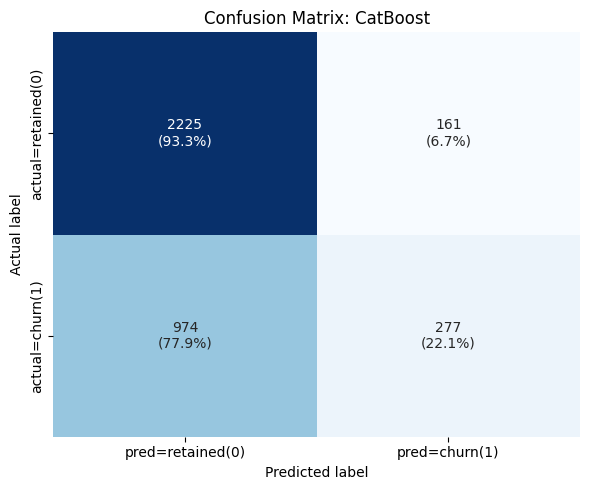

best_model_name: CatBoost
                    pred=retained(0)  pred=churn(1)
actual=retained(0)              2225            161
actual=churn(1)                  974            277


In [7]:
best_model_name = results_df.loc[0, "model"]
best_y_pred = model_artifacts[best_model_name]["y_pred"]

cm = confusion_matrix(y_test, best_y_pred)
cm_rate = confusion_matrix(y_test, best_y_pred, normalize="true")

annot = [
    [f"{count}\n({rate:.1%})" for count, rate in zip(count_row, rate_row)]
    for count_row, rate_row in zip(cm, cm_rate)
]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["pred=retained(0)", "pred=churn(1)"],
    yticklabels=["actual=retained(0)", "actual=churn(1)"],
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.tight_layout()
plt.show()

print(f"best_model_name: {best_model_name}")
print(pd.DataFrame(cm, index=["actual=retained(0)", "actual=churn(1)"], columns=["pred=retained(0)", "pred=churn(1)"]))
